In [1]:
from escripts import eplots
from escripts import eMCMC
from escripts import edata
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt

In [2]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Donnan24_GAL.txt',
             '/Users/eb35267/Desktop/code/home/data/Mcleod_24.txt']
data_labels = ['Donnan+24', 'McLeod+24']
z = 11
sorted_data = edata.get_sorted(file_names, data_labels, include_zs = [z])
compressed_data = edata.reduce(sorted_data)

Skipping $z = 9.0
Skipping $z = 10.0
Skipping $z = 12.5
Skipping $z = 13.5
Skipping $z = 14.5


In [3]:
sorted_data

[[[11.0,
   0.5,
   array([-21.25, -20.75, -20.25, -19.75, -19.25, -18.75, -18.25]),
   array([7.00e-06, 1.40e-05, 3.80e-05, 1.00e-04, 1.44e-04, 2.34e-04,
          6.41e-04]),
   array([5.00e-06, 1.10e-05, 1.60e-05, 3.70e-05, 6.70e-05, 1.06e-04,
          3.00e-04]),
   array([5.00e-06, 8.00e-06, 1.40e-05, 3.20e-05, 6.30e-05, 9.60e-05,
          2.91e-04]),
   array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]),
   'Donnan+24'],
  [11.0,
   0.5,
   array([-22.57, -21.8 , -20.8 , -20.05, -19.55, -18.85, -18.23]),
   array([1.200e-07, 1.290e-06, 1.254e-05, 3.974e-05, 9.863e-05, 2.349e-04,
          6.308e-04]),
   array([1.200e-07, 1.280e-06, 4.280e-06, 1.340e-05, 4.197e-05, 9.190e-05,
          2.865e-04]),
   array([1.200e-07, 1.280e-06, 4.280e-06, 1.340e-05, 4.197e-05, 9.190e-05,
          2.865e-04]),
   array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]),
   'McLeod+24']]]

In [4]:
params = eMCMC.build_param_data({'dsigdz': {'fit': False, 'value': 0}, 'dalphadz': {'fit': False, 'value':0}, 'dbetadz': 
                                 {'fit':False, 'value':0}, 'dlogedz': {'fit':False, 'value':0}, 'dlogMcdz':{'fit':False, 'value':0}})

In [ ]:
my_UVLF = eMCMC.UVLF(sorted_data, params)

In [23]:
low_z_fit = [0.67, -1.2, 12.11, -0.82, 0, 0]

<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_31340/4270938371.py:21: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f'UVLF at $z\simeq{z}$')


Text(-16.5, 2e-10, '$^1$Donnan+24, McLeod+24')

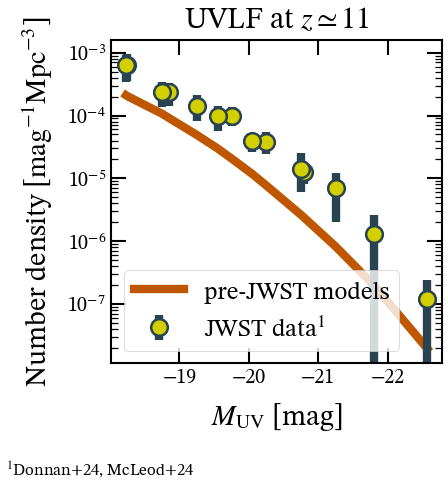

In [8]:
fig, ax = plt.subplots()
fig.set_dpi(60)
multiple = 1.5
fig.set_size_inches(multiple*4.75, multiple*4.67)
plot_xdat, plot_xerr = my_UVLF.data[0][2], my_UVLF.data[0][5]
zdat, zerr = compressed_data[0][0], compressed_data[0][1]
ax.plot(plot_xdat, my_UVLF.UVLF_wrapper(zdat, zerr, plot_xdat, plot_xerr, low_z_fit), label = fr'pre-JWST models', color = eplots.orange)
ax.invert_xaxis()
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.set_ylabel(r'Number density [$\rm{mag}^{-1} \rm{Mpc}^{-3}$]')
ax.set_xlabel(r'$M_{\rm{UV}}$ [mag]')

zdat, zerr, xdat, ydat, yerr_upper, yerr_lower, xerr = compressed_data[0]

ax.errorbar(xdat, ydat, yerr=[yerr_lower, yerr_upper],
            capsize=0, label='JWST data$^1$',
            markeredgecolor=eplots.navy, markeredgewidth=3, fmt='o',
            markerfacecolor=eplots.yellow, ecolor=eplots.navy)

ax.legend()
ax.set_title(f'UVLF at $z\simeq{z}$')
ax.set_yscale('log')

ax.text(-16.5, 2e-10, r'$^1$Donnan+24, McLeod+24', fontsize = 20)

#fig.savefig('/Users/eb35267/Desktop/figures/Talkito25/UVLF.png', bbox_inches='tight')

<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_31340/1438791010.py:22: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f'UVLF at $z\simeq{z}$')
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_31340/1438791010.py:16: RuntimeWarning: divide by zero encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), zorder = 0, ls = '-', colors = eplots.navy,


Text(-16.5, -9, '$^1$Donnan+24, McLeod+24')

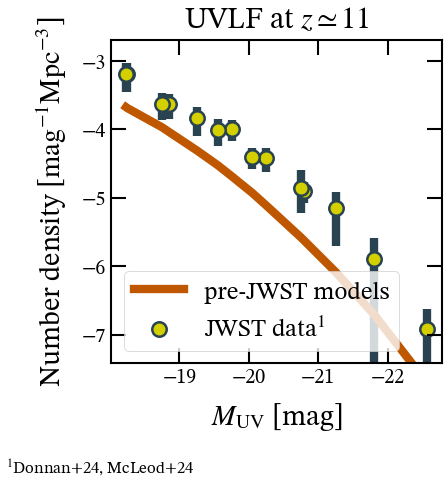

In [15]:
fig, ax = plt.subplots()
fig.set_dpi(60)
multiple = 1.5
fig.set_size_inches(multiple*4.75, multiple*4.67)
plot_xdat, plot_xerr = my_UVLF.data[0][2], my_UVLF.data[0][5]
zdat, zerr = compressed_data[0][0], compressed_data[0][1]
ax.plot(plot_xdat, np.log10(my_UVLF.UVLF_wrapper(zdat, zerr, plot_xdat, plot_xerr, low_z_fit)), label = fr'pre-JWST models', color = eplots.orange)
ax.invert_xaxis()
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.set_ylabel(r'Number density [$\rm{mag}^{-1} \rm{Mpc}^{-3}$]')
ax.set_xlabel(r'$M_{\rm{UV}}$ [mag]')

zdat, zerr, xdat, ydat, yerr_upper, yerr_lower, xerr = compressed_data[0]

ax.scatter(xdat, np.log10(ydat), label='JWST data$^1$', marker='o', c=eplots.yellow, edgecolors = eplots.navy, s = 300, linewidth = 3)
ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), zorder = 0, ls = '-', colors = eplots.navy, 
          linewidth =10)



ax.legend()
ax.set_title(f'UVLF at $z\simeq{z}$')
ax.set_ylim(np.min(np.log10(ydat))-0.5, np.max(np.log10(ydat))+0.5)

ax.text(-16.5, -9, r'$^1$Donnan+24, McLeod+24', fontsize = 20)